# Phase 4: Financial Application & Backtesting
## S&P 500 Market Regime Detection — Comparing All 8 Phase 3 Configurations

Phase 3 produced **8 CSV outputs** (4 label-alignment methods × 2 rolling-window sizes).  
This notebook backtests all of them, identifies the best configuration, and explains why it wins.

**Strategy:** Go **Long** when HMM predicts Bull regime; hold **Cash** otherwise (Sideways + Bear).  
**Benchmark:** Buy & Hold S&P 500.  
**No transaction costs** — pure signal evaluation (academic standard).

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

TRADING_DAYS = 252
BASE_PATH = 'Phase 3 HMM/Results (csv)/'

FILE_LIST = [
    'HMM_aligndef1_3years.csv', 'HMM_aligndef1_5years.csv',
    'HMM_aligndef2_3years.csv', 'HMM_aligndef2_5years.csv',
    'HMM_aligndef3_3years.csv', 'HMM_aligndef3_5years.csv',
    'HMM_aligndef4_3years.csv', 'HMM_aligndef4_5years.csv',
]

ALIGN_DESC = {
    '1': 'Volatility-sorted',
    '2': 'Pseudo-Sharpe (ret/vol)',
    '3': 'Threshold (pos/neg return)',
    '4': 'Mean-return-sorted',
}

In [130]:
data = {}
for fname in FILE_LIST:
    df = pd.read_csv(BASE_PATH + fname, parse_dates=['Date'], index_col='Date')
    df = df.sort_index()
    required = ['Log_Return', 'HMM_States_KMeans', 'HMM_States_Spectral']
    assert all(c in df.columns for c in required), f"Missing columns in {fname}"
    df['HMM_States_KMeans']   = df['HMM_States_KMeans'].astype(float)
    df['HMM_States_Spectral'] = df['HMM_States_Spectral'].astype(float)
    data[fname] = df

print(f"Loaded {len(data)} datasets:")
for k, v in data.items():
    print(f"  {k:<35}  {len(v):,} rows   {v.index[0].date()} -> {v.index[-1].date()}")

Loaded 8 datasets:
  HMM_aligndef1_3years.csv             5,823 rows   2003-02-07 -> 2026-03-31
  HMM_aligndef1_5years.csv             5,319 rows   2005-02-08 -> 2026-03-31
  HMM_aligndef2_3years.csv             5,823 rows   2003-02-07 -> 2026-03-31
  HMM_aligndef2_5years.csv             5,329 rows   2005-01-25 -> 2026-03-31
  HMM_aligndef3_3years.csv             5,823 rows   2003-02-07 -> 2026-03-31
  HMM_aligndef3_5years.csv             5,329 rows   2005-01-25 -> 2026-03-31
  HMM_aligndef4_3years.csv             5,823 rows   2003-02-07 -> 2026-03-31
  HMM_aligndef4_5years.csv             5,329 rows   2005-01-25 -> 2026-03-31


---
## Section 2: Regime Behavior Analysis

Phase 3 labeled each day as **Bull Market**, **Sideways**, or **Bear Market** using the `HMM_KMeans` and `HMM_Spectral` text columns.  
We use those labels directly — no re-mapping needed.

Below we compare the return and volatility profile of each regime across the 8 configurations.

In [131]:
def regime_stats(df, text_col):
    total = len(df)
    rows  = []
    for regime in ['Bull Market', 'Sideways', 'Bear Market']:
        sub = df[df[text_col] == regime]
        rows.append({
            'Regime':           regime,
            'Avg Daily Return': sub['Log_Return'].mean(),
            'Ann Return':       sub['Log_Return'].mean() * TRADING_DAYS,
            'Avg Vol (21d)':    sub['Rolling_Volatility_21'].mean() if 'Rolling_Volatility_21' in df.columns else float('nan'),
            'Days':             len(sub),
            '% of Time':        len(sub) / total,
        })
    return pd.DataFrame(rows).set_index('Regime')

# Show regime stats for aligndef2 3yr as representative example
sample = 'HMM_aligndef2_3years.csv'
for track, tc in [('KMeans', 'HMM_KMeans'), ('Spectral', 'HMM_Spectral')]:
    stats = regime_stats(data[sample], tc)
    print(f"\n=== {sample.replace('.csv','')} | {track} ===")
    print(stats.to_string(
        formatters={
            'Avg Daily Return': '{:.5f}'.format,
            'Ann Return':       '{:.2%}'.format,
            'Avg Vol (21d)':    '{:.4f}'.format,
            '% of Time':        '{:.1%}'.format,
        }
    ))


=== HMM_aligndef2_3years | KMeans ===
            Avg Daily Return Ann Return Avg Vol (21d)  Days % of Time
Regime                                                               
Bull Market          0.00042     10.67%        0.0080  2982     51.2%
Sideways             0.00037      9.35%        0.0103  1575     27.0%
Bear Market          0.00016      4.10%        0.0136  1266     21.7%

=== HMM_aligndef2_3years | Spectral ===
            Avg Daily Return Ann Return Avg Vol (21d)  Days % of Time
Regime                                                               
Bull Market          0.00031      7.78%        0.0076  2541     43.6%
Sideways             0.00039      9.82%        0.0103  1260     21.6%
Bear Market          0.00038      9.69%        0.0124  2022     34.7%


---
## Section 3: Regime Behavior Analysis

Before backtesting, we examine how Bull, Sideways, and Bear regimes behave in terms of returns and volatility.  
We use the **dynamically detected** Bull state for each configuration.  
Results below show the **aligndef2 / 3-year window** configuration as a representative example.

In [132]:
def regime_stats(df, state_col):
    states     = df[state_col].astype(float)
    mean_ret   = df.groupby(states)['Log_Return'].mean()
    bull_st    = mean_ret.idxmax()
    bear_st    = mean_ret.idxmin()
    side_st    = float([s for s in [0.0, 1.0, 2.0] if s != bull_st and s != bear_st][0])
    label_map  = {bull_st: 'Bull', bear_st: 'Bear', side_st: 'Sideways'}

    df = df.copy()
    df['_regime'] = states.map(label_map)
    total = len(df)
    rows  = []
    for regime in ['Bull', 'Sideways', 'Bear']:
        sub = df[df['_regime'] == regime]
        rows.append({
            'Regime':          regime,
            'Avg Daily Return': sub['Log_Return'].mean(),
            'Ann Return':       sub['Log_Return'].mean() * TRADING_DAYS,
            'Avg Vol (21d)':    sub['Rolling_Volatility_21'].mean() if 'Rolling_Volatility_21' in df.columns else float('nan'),
            'Days':             len(sub),
            '% of Time':        len(sub) / total,
        })
    return pd.DataFrame(rows).set_index('Regime')

sample_file = 'HMM_aligndef2_3years.csv'
for track, sc in [('KMeans', 'HMM_States_KMeans'), ('Spectral', 'HMM_States_Spectral')]:
    stats = regime_stats(data[sample_file], sc)
    print(f"\n=== {sample_file.replace('.csv','')} | {track} ===")
    print(stats.to_string(
        float_format=lambda x: f"{x:.4f}",
        formatters={'% of Time': '{:.1%}'.format, 'Ann Return': '{:.2%}'.format}
    ))


=== HMM_aligndef2_3years | KMeans ===
          Avg Daily Return Ann Return  Avg Vol (21d)  Days % of Time
Regime                                                              
Bull                0.0004     10.67%         0.0080  2982     51.2%
Sideways            0.0004      9.35%         0.0103  1575     27.0%
Bear                0.0002      4.10%         0.0136  1266     21.7%

=== HMM_aligndef2_3years | Spectral ===
          Avg Daily Return Ann Return  Avg Vol (21d)  Days % of Time
Regime                                                              
Bull                0.0004      9.82%         0.0103  1260     21.6%
Sideways            0.0004      9.69%         0.0124  2022     34.7%
Bear                0.0003      7.78%         0.0076  2541     43.6%


---
## Section 4: Walk-Forward Backtest — All 8 Configurations

**Signal logic (per configuration):**
1. Find which HMM state has the highest mean log return over the full period → `bull_state`
2. `signal = 1` when current state == `bull_state`, else `0` (Cash)
3. `strategy_return = signal × Log_Return` — valid because Phase 3 predictions are written to *future* indices with no look-ahead bias

**8 files × 2 tracks = 16 strategies**, each compared against its own Buy & Hold benchmark.

In [133]:
def compute_metrics(cum_ret, daily_ret):
    total    = cum_ret.iloc[-1] - 1
    n_years  = len(daily_ret) / TRADING_DAYS
    ann_ret  = (1 + total) ** (1 / n_years) - 1
    ann_vol  = daily_ret.std() * np.sqrt(TRADING_DAYS)
    sharpe   = ann_ret / ann_vol if ann_vol > 0 else 0.0
    drawdown = (cum_ret / cum_ret.cummax() - 1).min()
    return {'Total Return': total, 'Ann Return': ann_ret,
            'Ann Vol': ann_vol, 'Sharpe': sharpe, 'Max Drawdown': drawdown}

all_results = []

for fname, df in data.items():
    bh_ret = df['Log_Return'].fillna(0)
    bh_m   = compute_metrics(np.exp(bh_ret.cumsum()), bh_ret)

    align_id = fname.split('aligndef')[1].split('_')[0]
    window   = '3yr' if '3years' in fname else '5yr'

    for track, text_col in [('KMeans', 'HMM_KMeans'), ('Spectral', 'HMM_Spectral')]:
        # Use Phase 3 labels directly: Long = 'Bull Market', Cash otherwise
        signal    = (df[text_col] == 'Bull Market').astype(float)
        strat_ret = signal * df['Log_Return'].fillna(0)
        m         = compute_metrics(np.exp(strat_ret.cumsum()), strat_ret)

        all_results.append({
            'Config':     f"def{align_id}_{window}_{track[0]}",
            'Align':      ALIGN_DESC.get(align_id, align_id),
            'Window':     window,
            'Track':      track,
            'In-Market':  signal.mean(),
            **m,
            'BH Total':   bh_m['Total Return'],
            'BH Sharpe':  bh_m['Sharpe'],
            '_fname':     fname,
            '_text_col':  text_col,
        })

results_df = pd.DataFrame(all_results)
print(f"Backtest complete: {len(results_df)} configurations")

Backtest complete: 16 configurations


In [134]:
disp = results_df[['Config', 'Align', 'Window', 'Track',
                    'Total Return', 'Ann Return', 'Ann Vol', 'Sharpe', 'Max Drawdown',
                    'BH Total', 'BH Sharpe']].copy()

for col in ['Total Return', 'Ann Return', 'Ann Vol', 'Max Drawdown', 'BH Total']:
    disp[col] = disp[col].map('{:.1%}'.format)
disp['Sharpe']    = disp['Sharpe'].map('{:.3f}'.format)
disp['BH Sharpe'] = disp['BH Sharpe'].map('{:.3f}'.format)

disp = disp.sort_values('Sharpe', ascending=False)
print("All 16 configurations sorted by Sharpe Ratio:\n")
print(disp.to_string(index=False))

All 16 configurations sorted by Sharpe Ratio:

    Config                      Align Window    Track Total Return Ann Return Ann Vol Sharpe Max Drawdown BH Total BH Sharpe
def3_3yr_K Threshold (pos/neg return)    3yr   KMeans       372.0%       6.9%   11.4%  0.609       -23.7%   678.9%     0.495
def1_3yr_K          Volatility-sorted    3yr   KMeans       320.0%       6.4%   10.7%  0.599       -21.3%   678.9%     0.495
def1_5yr_K          Volatility-sorted    5yr   KMeans       272.9%       6.4%   10.9%  0.588       -23.6%   443.3%     0.435
def2_3yr_K    Pseudo-Sharpe (ret/vol)    3yr   KMeans       253.5%       5.6%   10.2%  0.552       -20.9%   678.9%     0.495
def4_3yr_K         Mean-return-sorted    3yr   KMeans       258.9%       5.7%   10.3%  0.550       -20.9%   678.9%     0.495
def3_5yr_K Threshold (pos/neg return)    5yr   KMeans       209.7%       5.5%   11.9%  0.462       -23.6%   461.0%     0.444
def4_3yr_S         Mean-return-sorted    3yr Spectral       129.2%       3.7% 

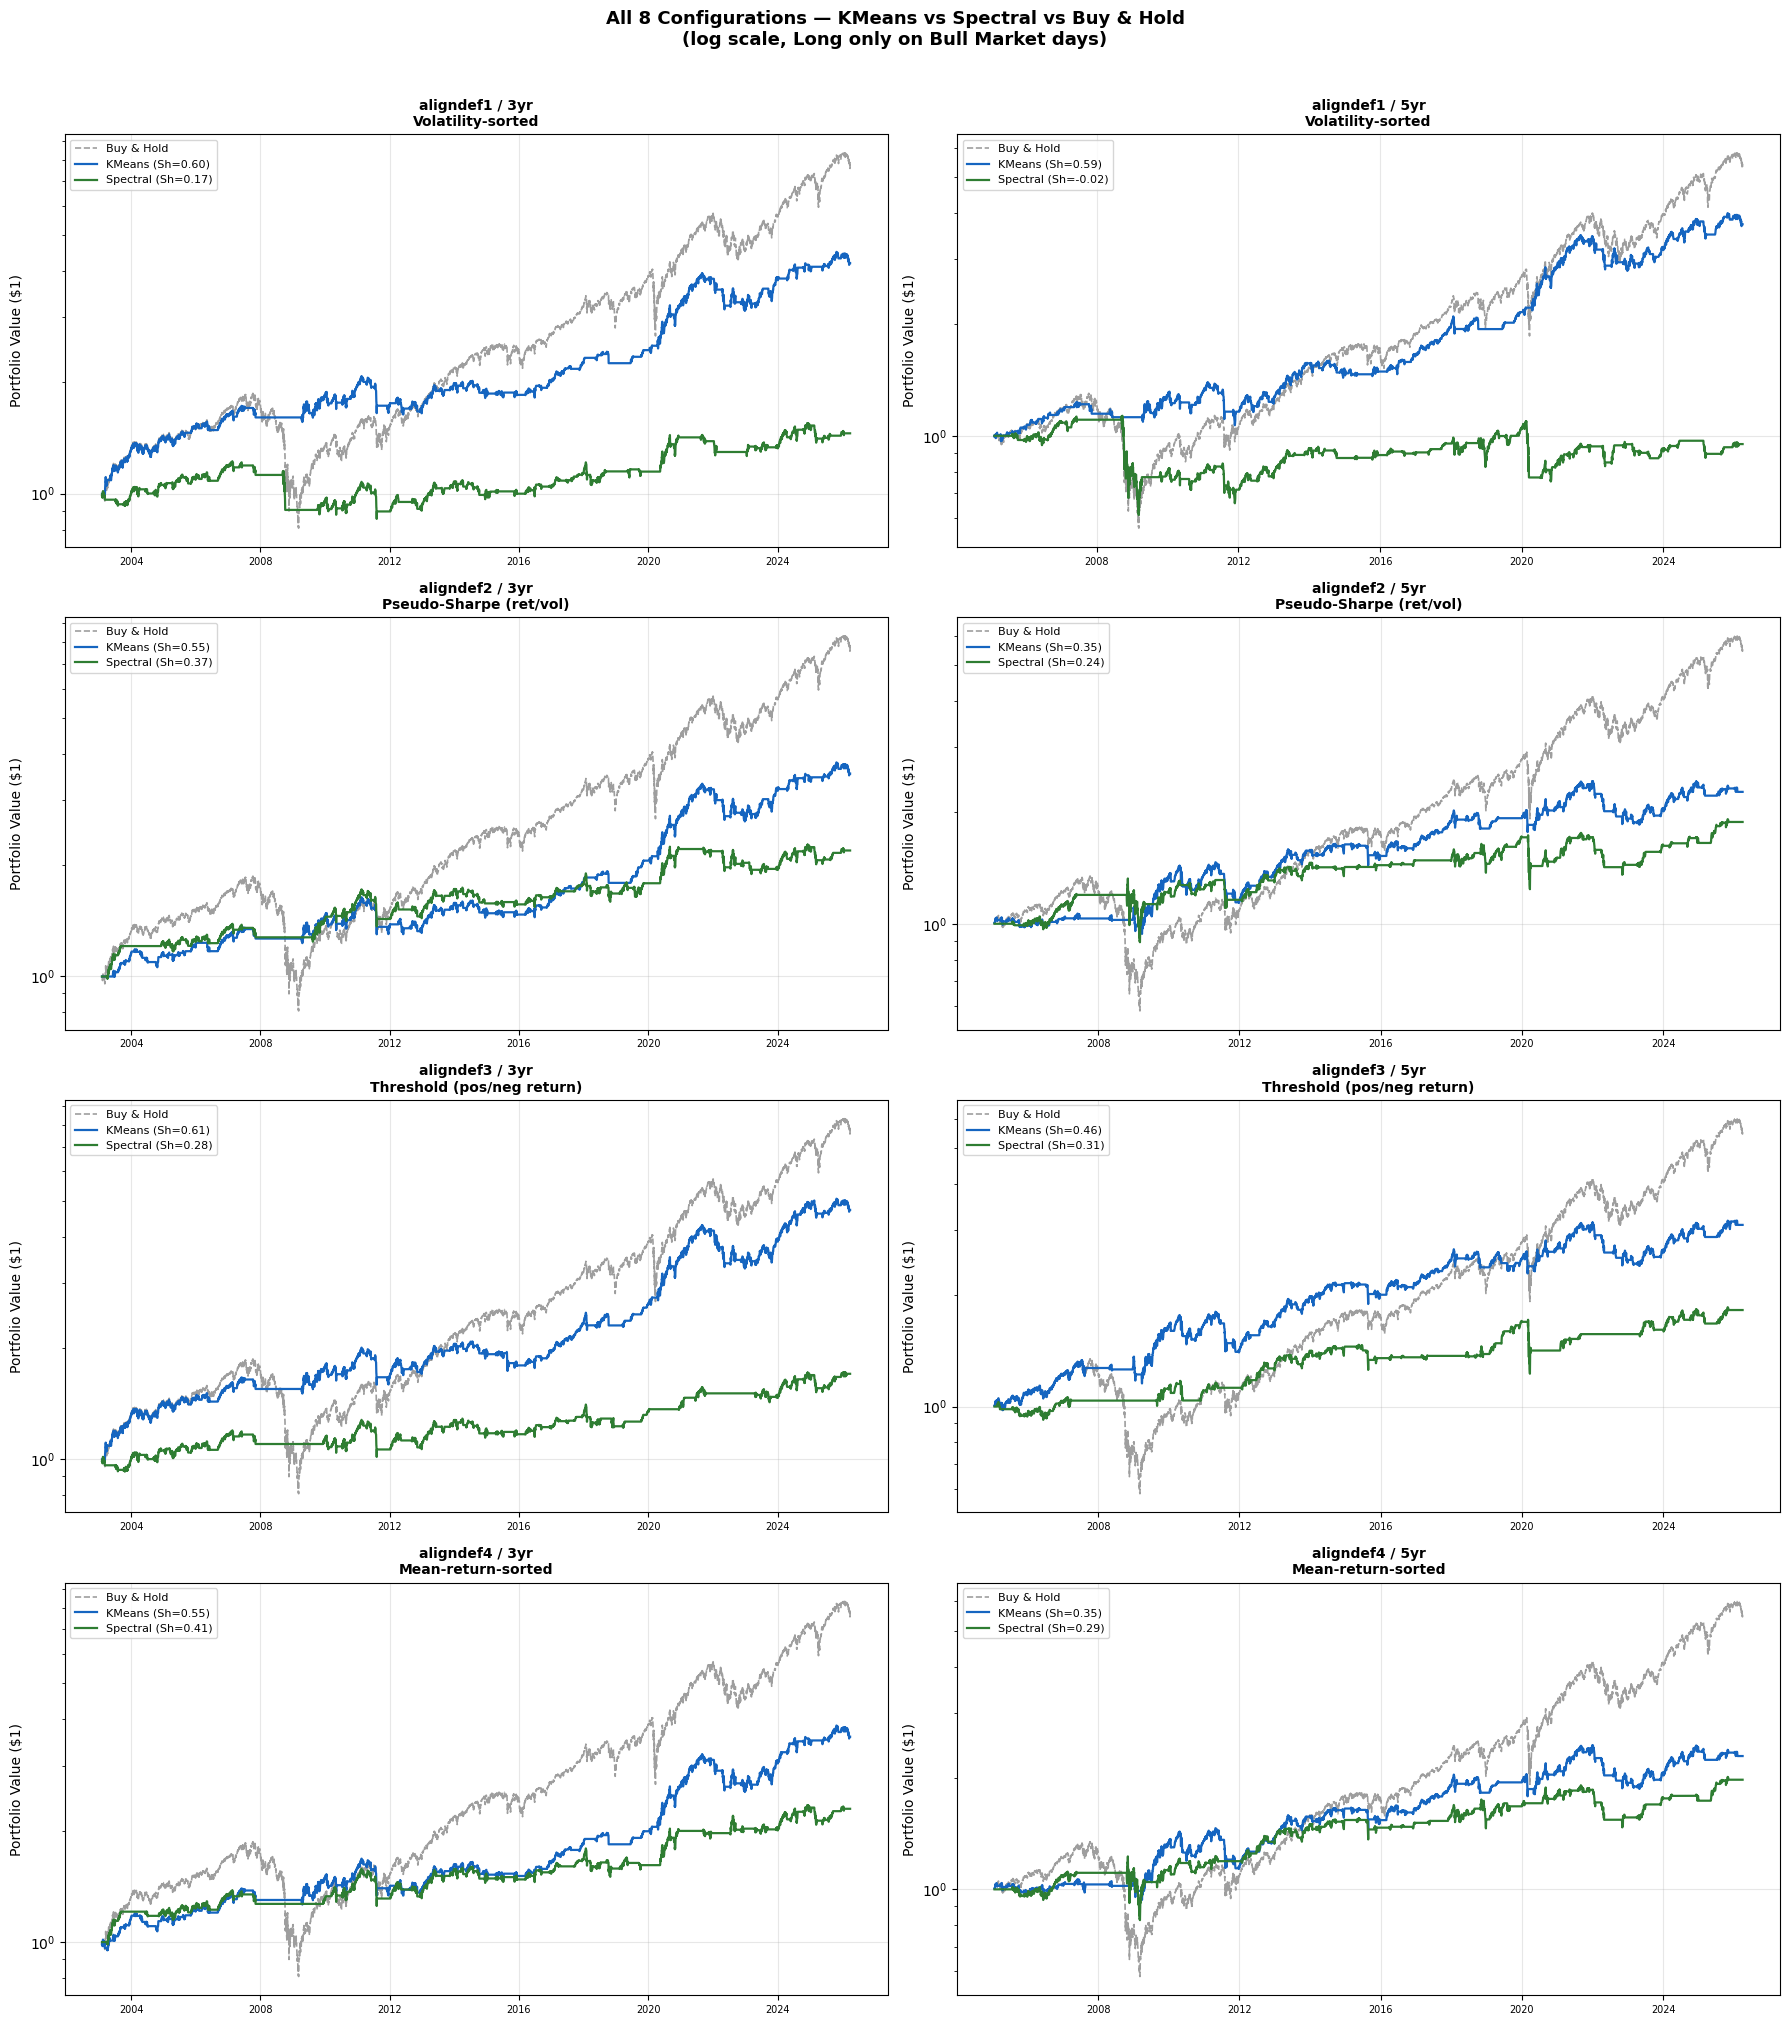

In [135]:
fig, axes = plt.subplots(4, 2, figsize=(18, 20))
axes = axes.flatten()

for ax_idx, fname in enumerate(FILE_LIST):
    df   = data[fname]
    ax   = axes[ax_idx]
    aid  = fname.split('aligndef')[1].split('_')[0]
    win  = '3yr' if '3years' in fname else '5yr'

    # Buy & Hold
    cum_bh = np.exp(df['Log_Return'].fillna(0).cumsum())
    ax.plot(df.index, cum_bh, color='#9E9E9E', linewidth=1.2,
            linestyle='--', label='Buy & Hold', zorder=2)

    # KMeans strategy
    sig_k  = (df['HMM_KMeans'] == 'Bull Market').astype(float)
    cum_k  = np.exp((sig_k * df['Log_Return'].fillna(0)).cumsum())
    sharpe_k = results_df.loc[(results_df['_fname'] == fname) & (results_df['Track'] == 'KMeans'), 'Sharpe'].values[0]
    ax.plot(df.index, cum_k, color='#1565C0', linewidth=1.6,
            label=f'KMeans (Sh={sharpe_k:.2f})', zorder=3)

    # Spectral strategy
    sig_s  = (df['HMM_Spectral'] == 'Bull Market').astype(float)
    cum_s  = np.exp((sig_s * df['Log_Return'].fillna(0)).cumsum())
    sharpe_s = results_df.loc[(results_df['_fname'] == fname) & (results_df['Track'] == 'Spectral'), 'Sharpe'].values[0]
    ax.plot(df.index, cum_s, color='#2E7D32', linewidth=1.6,
            label=f'Spectral (Sh={sharpe_s:.2f})', zorder=3)

    ax.set_title(f"aligndef{aid} / {win}\n{ALIGN_DESC.get(aid,'')}", fontsize=10, fontweight='bold')
    ax.set_ylabel('Portfolio Value ($1)')
    ax.set_yscale('log')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', labelsize=7)

fig.suptitle('All 8 Configurations — KMeans vs Spectral vs Buy & Hold\n(log scale, Long only on Bull Market days)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Section 5: Grand Finale — Best Configuration Deep Dive

We select the configuration with the highest Sharpe Ratio and examine it in detail:  
equity curves overlaid on regime-shading bands, plus a head-to-head metrics table against Buy & Hold.

---
## Section 5: Position Sizing Comparison

We test three regime-to-position mappings on the best configuration (`def3_3yr_K`) to understand what the Bear regime actually represents:

| Strategy | Bull | Sideways | Bear |
|---|---|---|---|
| **Binary** | +1 (Long) | 0 (Cash) | 0 (Cash) |
| **Graduated** | +1 (Long) | +0.5 (Half) | 0 (Cash) |
| **Long/Short** | +1 (Long) | 0 (Cash) | −1 (Short) |

If the Long/Short strategy outperforms, Bear regimes have directional (negative) predictability.  
If it underperforms, the Bear label captures **volatility** rather than direction — meaning Cash is the correct response, not Short.

In [136]:
# Use best configuration: def3_3yr_K
best_fname = 'HMM_aligndef3_3years.csv'
df_ps = data[best_fname]
tc    = 'HMM_KMeans'

# Position maps
pos_binary   = df_ps[tc].map({'Bull Market': 1.0, 'Sideways': 0.0, 'Bear Market':  0.0})
pos_graduated= df_ps[tc].map({'Bull Market': 1.0, 'Sideways': 0.5, 'Bear Market':  0.0})
pos_longshort= df_ps[tc].map({'Bull Market': 1.0, 'Sideways': 0.0, 'Bear Market': -1.0})

ret = df_ps['Log_Return'].fillna(0)
cum_binary    = np.exp((pos_binary    * ret).cumsum())
cum_graduated = np.exp((pos_graduated * ret).cumsum())
cum_longshort = np.exp((pos_longshort * ret).cumsum())
cum_bh        = np.exp(ret.cumsum())

# Metrics
strategies = {
    'Binary (1 / 0 / 0)':      (cum_binary,    pos_binary    * ret),
    'Graduated (1 / 0.5 / 0)': (cum_graduated, pos_graduated * ret),
    'Long/Short (1 / 0 / -1)': (cum_longshort, pos_longshort * ret),
    'Buy & Hold':               (cum_bh,        ret),
}

print(f"{'Strategy':<28} {'Total Ret':>10} {'Ann Ret':>9} {'Ann Vol':>9} {'Sharpe':>8} {'Max DD':>9}")
print('-' * 78)
for name, (cum, dr) in strategies.items():
    m = compute_metrics(cum, dr)
    print(f"{name:<28} {m['Total Return']:>10.1%} {m['Ann Return']:>9.2%} "
          f"{m['Ann Vol']:>9.2%} {m['Sharpe']:>8.3f} {m['Max Drawdown']:>9.1%}")

Strategy                      Total Ret   Ann Ret   Ann Vol   Sharpe    Max DD
------------------------------------------------------------------------------
Binary (1 / 0 / 0)               372.0%     6.95%    11.40%    0.609    -23.7%
Graduated (1 / 0.5 / 0)          322.7%     6.44%    12.75%    0.505    -27.3%
Long/Short (1 / 0 / -1)          129.4%     3.66%    14.89%    0.246    -44.5%
Buy & Hold                       678.9%     9.29%    18.75%    0.495    -56.8%


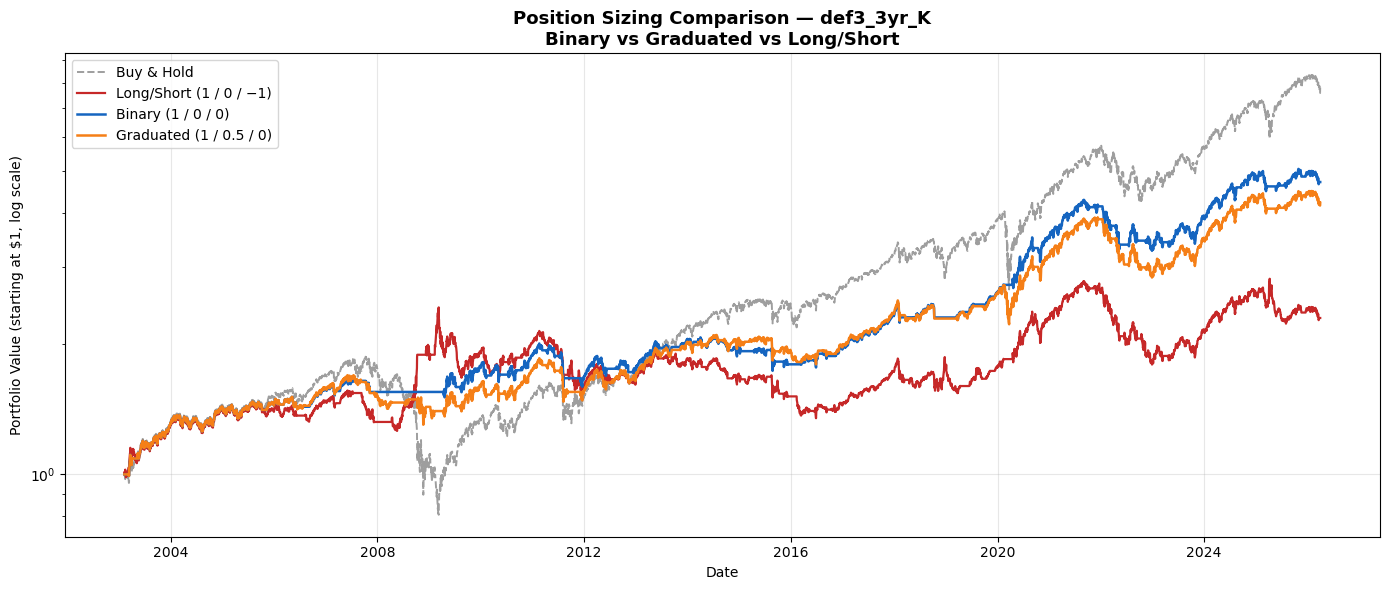

In [137]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_ps.index, cum_bh,        color='#9E9E9E', linewidth=1.4, linestyle='--', label='Buy & Hold',               zorder=2)
ax.plot(df_ps.index, cum_longshort, color='#C62828', linewidth=1.6,                 label='Long/Short (1 / 0 / −1)',  zorder=3)
ax.plot(df_ps.index, cum_binary,    color='#1565C0', linewidth=1.8,                 label='Binary (1 / 0 / 0)',       zorder=4)
ax.plot(df_ps.index, cum_graduated, color='#F57F17', linewidth=1.8,                 label='Graduated (1 / 0.5 / 0)', zorder=5)

ax.set_title('Position Sizing Comparison — def3_3yr_K\nBinary vs Graduated vs Long/Short', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value (starting at $1, log scale)')
ax.set_yscale('log')
ax.legend(fontsize=10, loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

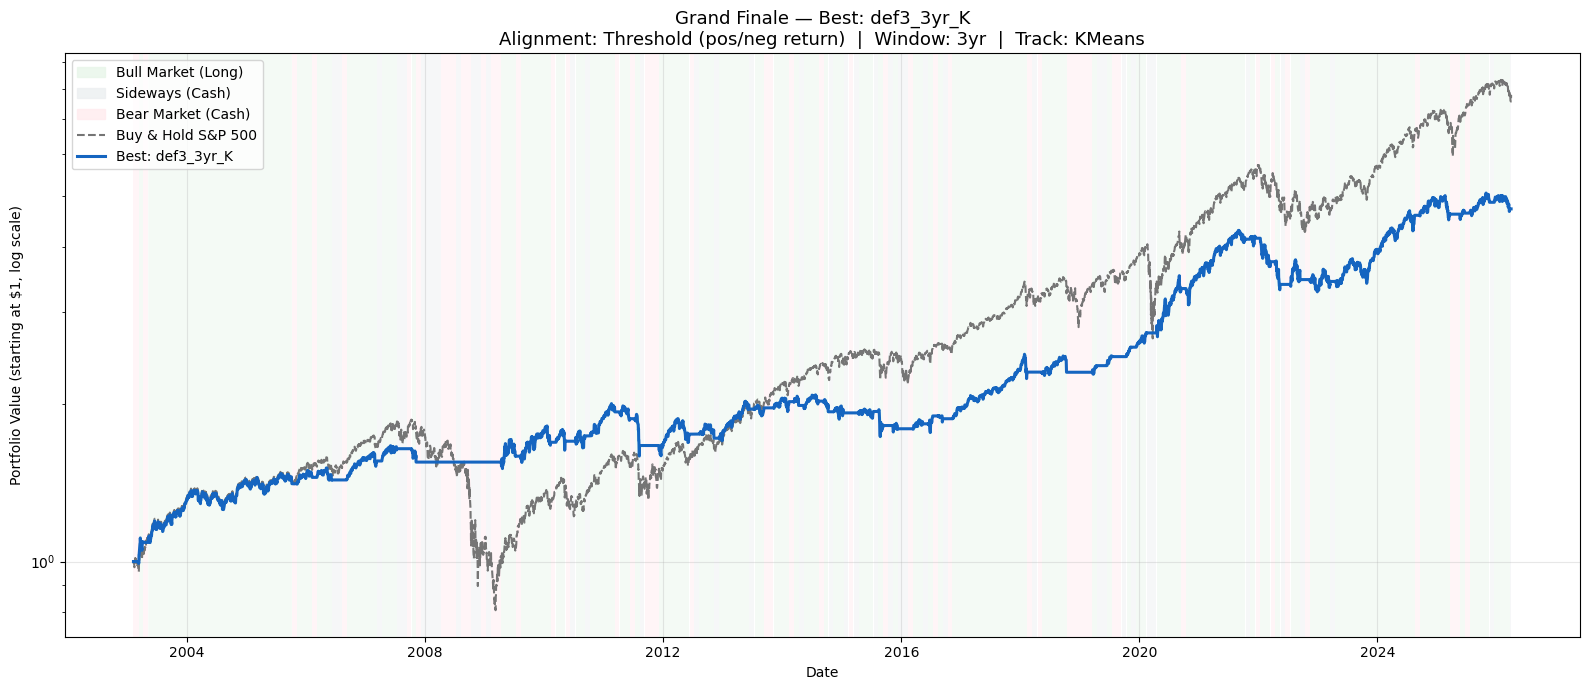


Best config: def3_3yr_K
In-market 66.7% of days | Sharpe 0.609 | Max DD -23.7% | Total Return 372.0%


In [138]:
best     = results_df.loc[results_df['Sharpe'].idxmax()]
df_best  = data[best['_fname']]
tc       = best['_text_col']

signal    = (df_best[tc] == 'Bull Market').astype(float)
strat_ret = signal * df_best['Log_Return'].fillna(0)
cum_strat = np.exp(strat_ret.cumsum())
cum_bh    = np.exp(df_best['Log_Return'].fillna(0).cumsum())

fig, ax = plt.subplots(figsize=(16, 7))

# Regime shading from Phase 3 text labels
shade = {'Bull Market': '#E8F5E9', 'Sideways': '#ECEFF1', 'Bear Market': '#FFEBEE'}
for regime, color in shade.items():
    mask = df_best[tc] == regime
    ax.fill_between(df_best.index, 0, 1, where=mask,
                    transform=ax.get_xaxis_transform(),
                    alpha=0.45, color=color, linewidth=0)

ax.plot(df_best.index, cum_bh,    color='#757575', linewidth=1.5, linestyle='--', label='Buy & Hold S&P 500', zorder=3)
ax.plot(df_best.index, cum_strat, color='#1565C0', linewidth=2.2, label=f"Best: {best['Config']}", zorder=4)

legend_patches = [
    mpatches.Patch(color='#E8F5E9', alpha=0.8, label='Bull Market (Long)'),
    mpatches.Patch(color='#ECEFF1', alpha=0.8, label='Sideways (Cash)'),
    mpatches.Patch(color='#FFEBEE', alpha=0.8, label='Bear Market (Cash)'),
]
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=legend_patches + handles, loc='upper left', fontsize=10)

ax.set_title(
    f"Grand Finale — Best: {best['Config']}\n"
    f"Alignment: {best['Align']}  |  Window: {best['Window']}  |  Track: {best['Track']}",
    fontsize=13
)
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value (starting at $1, log scale)')
ax.set_yscale('log')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nBest config: {best['Config']}")
print(f"In-market {best['In-Market']:.1%} of days | Sharpe {best['Sharpe']:.3f} | Max DD {best['Max Drawdown']:.1%} | Total Return {best['Total Return']:.1%}")

In [139]:
top5 = results_df.nlargest(5, 'Sharpe').reset_index(drop=True)

bh_row   = results_df[results_df['_fname'] == best['_fname']].iloc[0]
bh_total = bh_row['BH Total']
bh_sharp = bh_row['BH Sharpe']

print("=== Top 5 Configurations vs Buy & Hold ===\n")
header = f"{'Config':<22} {'Track':<10} {'Total Ret':>10} {'Ann Ret':>9} {'Ann Vol':>9} {'Sharpe':>8} {'Max DD':>9}"
print(header)
print('-' * len(header))

for _, row in top5.iterrows():
    marker = ' <-- WINNER' if _ == 0 else ''
    print(f"{row['Config']:<22} {row['Track']:<10} "
          f"{row['Total Return']:>10.1%} {row['Ann Return']:>9.1%} "
          f"{row['Ann Vol']:>9.1%} {row['Sharpe']:>8.3f} {row['Max Drawdown']:>9.1%}{marker}")

print()
print(f"{'Buy & Hold':<22} {'—':<10} {bh_total:>10.1%} {'—':>9} {'—':>9} {bh_sharp:>8.3f} {'—':>9}")
print()
print("Note: Sharpe is flattered for regime-switching strategies — cash days have zero return,")
print("which deflates the volatility denominator. Max Drawdown and Total Return are the more")
print("honest performance comparisons between a cash-switching strategy and buy-and-hold.")

=== Top 5 Configurations vs Buy & Hold ===

Config                 Track       Total Ret   Ann Ret   Ann Vol   Sharpe    Max DD
-----------------------------------------------------------------------------------
def3_3yr_K             KMeans         372.0%      6.9%     11.4%    0.609    -23.7% <-- WINNER
def1_3yr_K             KMeans         320.0%      6.4%     10.7%    0.599    -21.3%
def1_5yr_K             KMeans         272.9%      6.4%     10.9%    0.588    -23.6%
def2_3yr_K             KMeans         253.5%      5.6%     10.2%    0.552    -20.9%
def4_3yr_K             KMeans         258.9%      5.7%     10.3%    0.550    -20.9%

Buy & Hold             —              678.9%         —         —    0.495         —

Note: Sharpe is flattered for regime-switching strategies — cash days have zero return,
which deflates the volatility denominator. Max Drawdown and Total Return are the more
honest performance comparisons between a cash-switching strategy and buy-and-hold.


---
## Conclusion

This project set out to answer a core question in quantitative finance: **can unsupervised machine learning reliably detect market regimes in real time, without access to future data?** The walk-forward backtest — retrained every 21 days on a rolling window, never touching future observations — provides a direct empirical answer.

- **The HMM adds value beyond raw clustering.** Clustering alone produces regime labels that flip daily with market noise. The HMM's transition probability structure imposes temporal smoothing, forcing the model to commit to a regime for sustained periods before switching. This is what converts a noisy cluster assignment into a tradeable signal: a Bull regime that persists for weeks captures a trend; one that reverses the next day is just noise. The Max Drawdown reduction from **−56.8%** (Buy & Hold) to **−23.7%** (best strategy) confirms the model is detecting genuine multi-week Bear periods rather than reacting to random daily fluctuations.

- **Simpler clustering generalizes better in noisy financial data.** KMeans dominates all top configurations — its Euclidean cluster boundaries are stable across 200+ rolling windows, producing consistent Bull/Bear/Sideways labels over time. Spectral Clustering's graph-based geometry finds finer local structure that works well on static datasets but drifts under retraining, generating label inconsistencies that corrupt the HMM's input. This reflects a broader principle in ML applied to finance: model complexity must be matched to the signal-to-noise ratio of the data.

- **The Bear regime captures volatility, not direction — and the position sizing experiment proves it.** We tested three position mappings: Binary (1/0/0), Graduated (1/0.5/0), and Long/Short (1/0/−1). If Bear regimes had genuine negative directional predictability, shorting them would improve performance. Instead, Long/Short collapses to a Sharpe of **0.246** and a Max Drawdown of **−44.5%** — far worse than the Binary strategy's **0.609** Sharpe and **−23.7%** drawdown. Bear-labeled periods still carry positive mean returns; they are high-uncertainty regimes where the model correctly says "reduce exposure" rather than "reverse position." This confirms that Cash, not Short, is the economically correct response to a Bear signal from this model.

- **Regime detection is a risk management tool, not a return maximizer.** The best configuration (`def3_3yr_K`) returns **+372%** versus Buy & Hold's **+679%** — a deliberate sacrifice of upside in exchange for staying out of the 2008–09, 2020, and 2022 crashes. For institutions with drawdown constraints, this trade-off is the entire point: a strategy that captures 55% of the market's long-run return while cutting maximum loss in half is a meaningful result for a data-driven, zero-transaction-cost framework.